In [1]:
import shapely.geometry as geometry
from shapely.ops import linemerge, unary_union, polygonize
from shapely.geometry import mapping

import networkx as nx
import pandas as pd
import numpy as np
import pickle

import matplotlib.pyplot as plt

from haversine import haversine

from convenient_pickle import *

import os
import time
import gc

safe_cwd = os.getcwd()
begin = time.time()

In [2]:
def load_pickles(prefix):
    G = load_pickle('pickle_folder/'+prefix + '/' + prefix+'_graph.pkl')
    total_result_nodes = load_pickle('pickle_folder/'+prefix + '/' + prefix+'_total_result_nodes.pkl')
    total_result_ways = load_pickle('pickle_folder/'+prefix + '/' + prefix+'_total_result_ways.pkl')
    used_bboxes = load_pickle('pickle_folder/'+prefix + '/' + prefix+'_used_bboxes.pkl')
    return G, total_result_nodes, total_result_ways, used_bboxes

def lite_load_pickles(prefix):
    G = load_pickle('pickle_folder/'+prefix + '/' + prefix+'_graph.pkl')
    total_result_ways = load_pickle('pickle_folder/'+prefix + '/' + prefix+'_total_result_ways.pkl')
    return G, total_result_ways

def make_ways_lighter(total_result_ways) :
    ways_dict = dict()
    ways_dict['ways'] = dict()
    ways_dict['nodes'] = dict()
    for way in total_result_ways: 
        way_id = way.id
        node_ids = []
        for node in way.nodes: 
            node_ids.append(node.id)
            ways_dict[node.id] = {'lat': float(node.lat),'lon': float(node.lon)}
        ways_dict['ways'][way_id] = node_ids
    return ways_dict
            

# Load in graph and total ways data. Get median distance between 2 nodes for entire graph; we delete the graph at the end for now because it might not be useful

In [3]:
def get_edge_distance(node1, node2): 
    lat1 = float(node1['lat'])
    lon1 = float(node1['lon'])
    lat2 = float(node2['lat'])
    lon2 = float(node2['lon'])

    return haversine((lat1,lon1), (lat2, lon2))


In [4]:
#load in data
prefix = '06_26_2026'
#total_result_ways = load_pickle('pickle_folder/'+prefix + '/' + prefix+'_total_result_ways.pkl')
G, total_result_ways = lite_load_pickles(prefix)

# Get lats and lons for all nodes
node_dict = dict() 

for way in total_result_ways: 
    for node in way.nodes: 
        node_dict[node.id] = {'lat': node.lat, 'lon': node.lon}

# Go through all nodes in node_dict, get neighbors in graph, find distance between unique pairs of neighbors, add to list

distance_list = []
distance_pairs = set()

for node in node_dict.keys(): 
    neighbors = [i for i in G.neighbors(node)]
    for neighbor in neighbors: 
        sorted_pair = tuple(sorted([node, neighbor]))
        if sorted_pair not in distance_pairs: 
            edge_distance = get_edge_distance(node_dict[neighbor], node_dict[node])
            distance_list.append(edge_distance)
            distance_pairs.add(sorted_pair)
del G
del node_dict
del distance_pairs
gc.collect()

16

In [5]:
median = np.median(np.array(distance_list))

In [6]:
print(median)

0.0070401946749102315


# Load in bike ways data

In [7]:
prefix_bike = '06_26_2026_just_bikes'
total_result_ways_bike = load_pickle('pickle_folder/'+prefix_bike + '/' + prefix_bike+'_total_result_ways.pkl')

# Trim out irrelevant bike ways

In [8]:
relevant_ways = {i.id:True for i in total_result_ways}
total_result_ways_bike = [i for i in total_result_ways_bike if i.id in relevant_ways]
del relevant_ways

# Get the distances

In [9]:
# I. Remove bike ways from total ways
# II. Go through all bike ways and convert to shapely. 
# III. Go through all ways, see if non-bike, then go through node pairs. 
#      A. For each node pair, collect distance between each node and all bike paths. 
#      B. Also collect distances between nodes. Average the pair, and then normalize for median. 

### Remove bike ways from total ways

In [10]:
bike_ways = {i.id for i in total_result_ways_bike}
total_result_ways = [i for i in total_result_ways if i.id not in bike_ways]
del bike_ways
gc.collect()

0

### Convert all bike ways to shapely

In [11]:
#from pyproj import Geod
from shapely.geometry import Point, LineString
from shapely.strtree import STRtree
from shapely.ops import nearest_points, linemerge, unary_union
from shapely.geometry import Point


In [12]:
shapely_bike_ways = []
for way in total_result_ways_bike: 
    coord_list = LineString([(i.lon, i.lat) for i in way.nodes])
    shapely_bike_ways.append(coord_list)
shapely_bike_ways = unary_union(linemerge(shapely_bike_ways))
total_result_ways_bike = shapely_bike_ways
del shapely_bike_ways
gc.collect()

14682367

In [13]:
if total_result_ways_bike.geom_type == "MultiLineString":
    total_result_ways_bike = list(total_result_ways_bike.geoms)
else:
    total_result_ways_bike = [total_result_ways_bike]

tree = STRtree(total_result_ways_bike)

### Go through all node pairs in non-bike. Refer to part III above.

In [71]:
dist_to_bike_list = []
test_normal_dists = []

for way in total_result_ways: 
    nodes = [i for i in way.nodes]
    for node_dex in range(len(nodes)-1): 
        first_node = nodes[node_dex]
        second_node = nodes[node_dex+1] 
        distance = haversine((first_node.lat, first_node.lon), (second_node.lat, second_node.lon))
        midpoint = Point((first_node.lon+second_node.lon)/2, (first_node.lat+second_node.lat)/2)
        dists = []
        n_idx = tree.nearest(midpoint)
        nearest = total_result_ways_bike[n_idx]
        p1, p2 = nearest_points(midpoint, nearest)
        normal_dist = haversine((p1.x, p1.y), (p2.x, p2.y))
        test_normal_dists.append((normal_dist, distance))
        normal_dist = (normal_dist) * distance/median
        dist_to_bike_list.append((normal_dist, distance/median))
        
        

In [72]:
total_distance = sum([i[0] for i in dist_to_bike_list])
total_count = sum([i[1] for i in dist_to_bike_list])

In [73]:
print(total_distance/total_count)

1.1280834769315147


In [53]:
from haversine import haversine

In [66]:
from matplotlib import pyplot as plt

In [67]:
pre_normalized_dists = [i[0] for i in test_normal_dists]

In [70]:
print(sum(pre_normalized_dists)/len(pre_normalized_dists))

0.99064554007122


(array([1.539726e+06, 3.844180e+05, 1.361420e+05, 5.597500e+04,
        2.876900e+04, 1.325500e+04, 1.669000e+03, 1.070000e+02,
        1.270000e+02, 1.700000e+01]),
 array([ 0.        ,  1.19995085,  2.39990169,  3.59985254,  4.79980338,
         5.99975423,  7.19970508,  8.39965592,  9.59960677, 10.79955762,
        11.99950846]),
 <BarContainer object of 10 artists>)

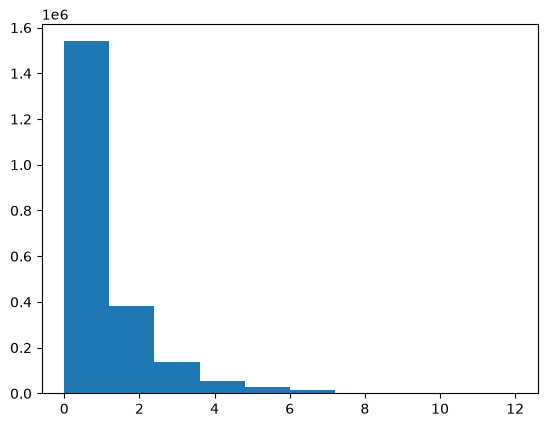

In [76]:
plt.hist(pre_normalized_dists)

In [90]:
np.median([i[1] for i in dist_to_bike_list])

np.float64(0.9674171639750454)

In [89]:
np.median([i[0] for i in dist_to_bike_list])

np.float64(0.5640030729488235)

In [92]:
np.median(pre_normalized_dists)

np.float64(0.5596307844630752)

In [93]:
np.mean([i[1] for i in dist_to_bike_list])

np.float64(2.4843677979700227)

In [97]:
total_distance/total_count

np.float64(1.1280834769315147)

In [95]:
np.mean(pre_normalized_dists)

np.float64(0.99064554007122)

In [98]:
median

np.float64(0.0070401946749102315)